# Dataset Loading and EDA


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Load dataset and convert to Pandas for heavy lifting
dataset = load_dataset("papluca/language-identification")
df_train = pd.DataFrame(dataset['train'])
df_test = pd.DataFrame(dataset['test'])

df_train.head(20)

,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .
5,pl,"S Jak sobie życzysz: Widzisz, jak Hitler zabij..."
6,ur,اس کے بارے میں ، سفید شادی کی شرح کے بعد سفید ...
7,sw,Zabuni ya ushindani pia imekuwa rahisi kwa sif...
8,tr,Devasa 12 yüzyıl abbatiale saint-Pierre-Et-Sai...
9,ur,موجودہ اثاثوں میں سے ایک کا اضافہ ہو سکتا ہے ۔


/tmp/ipykernel_9975/1722492648.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='labels', order=df_train['labels'].value_counts().index, palette='viridis')


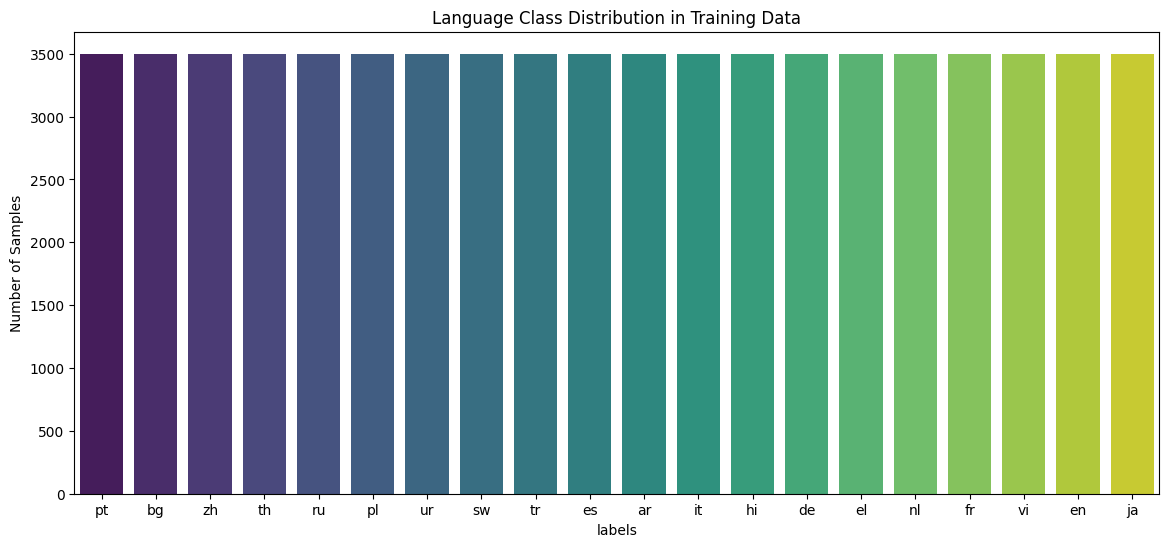

In [3]:
# 1. Check Class Distribution
plt.figure(figsize=(14, 6))
sns.countplot(data=df_train, x='labels', order=df_train['labels'].value_counts().index, palette='viridis')
plt.title('Language Class Distribution in Training Data')
plt.ylabel('Number of Samples')
plt.show()



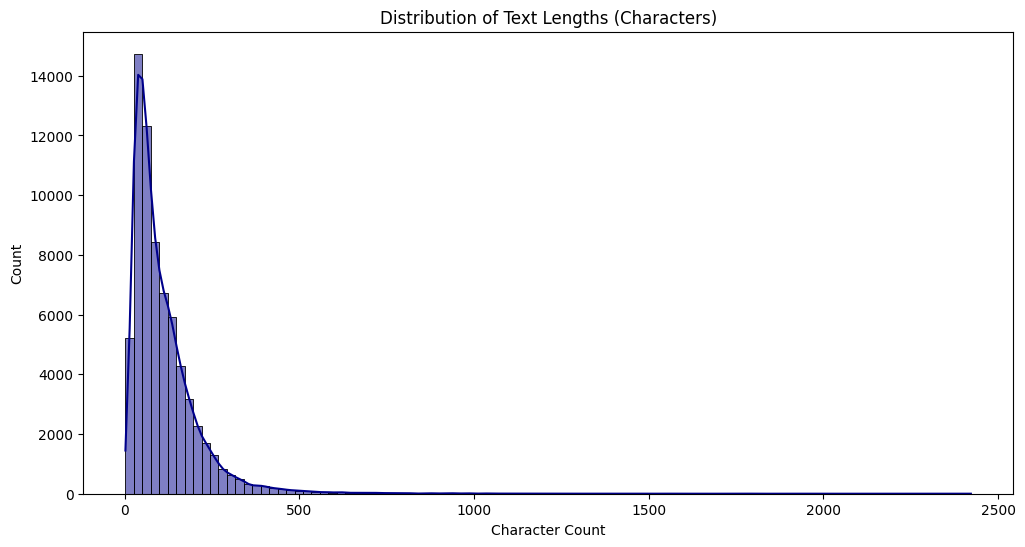

In [5]:
# 2. Text Length Analysis
df_train['text_length'] = df_train['text'].apply(len)
plt.figure(figsize=(12, 6))
sns.histplot(df_train['text_length'], bins=100, kde=True, color='darkblue')
plt.title('Distribution of Text Lengths (Characters)')
plt.xlabel('Character Count')
plt.show()

In [9]:
# 3. Identify Outliers (e.g., extremely short texts that lack linguistic features)
print("Samples with fewer than 8 characters:")
outliers = df_train[df_train['text_length'] < 8]
print(outliers)

Samples with fewer than 8 characters:
      labels     text  text_length
570       ur   وولف .            6
1246      ur    اور ؟            5
1382      th  แล้ว ไง            7
1909      tr  Çok iyi            7
2000      ur      میں            3
2694      el  Όνομα ;            7
3255      ur     فلیپ            4
7003      ur    ربط .            5
7525      sw  Yakua ?            7
8325      ur  آرٹ ورک            7
10244     el   Ή ίσως            6
11165     tr     Semt            4
12631     ur   جی ہاں            6
14557     tr  Yudum .            7
15307     ur   باؤر :            6
16017     ur  # نام ؟            7
17606     ur      اور            3
19522     ru   Это в.            6
20821     hi  # नाम ?            7
21434     ru  - имя ?            7
23683     hi  पड ़ ोस            7
25850     ur  مس میڈم            7
29100     tr      O '            3
29229     ar       حي            2
30268     ur  ٹھیک ہے            7
31011     bg  квартал            7
35289     ur  نصف

# Data Preprocessing

In [10]:
import re
import string

def refined_clean_text(text):
    text = str(text)

    # 1. Remove URLs and User Mentions (still pure noise)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)

    # 2. Remove ONLY Western digits, preserving Arabic/Hindi/etc. numerals
    text = re.sub(r'[0-9]+', '', text)

    # 3. Remove ONLY standard ASCII punctuation.
    # This leaves Tashkeel, Kanji, Cyrillic, and special marks completely intact.
    ascii_punctuation = re.escape(string.punctuation)
    text = re.sub(f'[{ascii_punctuation}]', ' ', text)

    # 4. Normalize whitespace and lowercase
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

print("Applying refined multilingual cleaning...")
df_train['clean_text'] = df_train['text'].apply(refined_clean_text)
df_test['clean_text'] = df_test['text'].apply(refined_clean_text)

Applying refined multilingual cleaning...


In [11]:
# Let's inspect how the cleaning affected the outliers we found earlier
print("\nBefore and After Cleaning (Short Texts):")
print(df_train.loc[outliers.index, ['text', 'clean_text']].head(15))


Before and After Cleaning (Short Texts):
          text clean_text
570     وولف .       وولف
1246     اور ؟      اور ؟
1382   แล้ว ไง    แล้ว ไง
1909   Çok iyi    çok iyi
2000       میں        میں
2694   Όνομα ;      όνομα
3255      فلیپ       فلیپ
7003     ربط .        ربط
7525   Yakua ?      yakua
8325   آرٹ ورک    آرٹ ورک
10244   Ή ίσως     ή ίσως
11165     Semt       semt
12631   جی ہاں     جی ہاں
14557  Yudum .      yudum
15307   باؤر :       باؤر


# Modeling: TFIDF + Char N-Gram
- This is the industry standard for language identification because it excels at picking up on specific character sequences (like "ção" in Portuguese or the specific character groupings in Urdu).

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 1. Build the Pipeline
# analyzer='char_wb' looks at character n-grams strictly inside word boundaries
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(1, 3), max_features=50000)),
    ('clf', LogisticRegression(max_iter=1000, n_jobs=-1))
])

print("Training the language detection model...")
# Use the cleaned text we just generated!
pipeline.fit(df_train['clean_text'], df_train['labels'])



Training the language detection model...


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(analyzer='char_wb', max_features=50000,
                                 ngram_range=(1, 3))),
                ('clf', LogisticRegression(max_iter=1000, n_jobs=-1))])

# Evaluation

In [14]:
# 2. Predict on the Test Set
print("Evaluating the model...")
y_pred = pipeline.predict(df_test['clean_text'])
y_true = df_test['labels']

# 3. Print Detailed Classification Report
classes = np.unique(y_true)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))


Evaluating the model...

Classification Report:

              precision    recall  f1-score   support

          ar       1.00      1.00      1.00       500
          bg       0.99      1.00      1.00       500
          de       1.00      1.00      1.00       500
          el       1.00      1.00      1.00       500
          en       1.00      1.00      1.00       500
          es       0.98      0.99      0.99       500
          fr       1.00      1.00      1.00       500
          hi       1.00      0.97      0.98       500
          it       0.99      0.99      0.99       500
          ja       1.00      1.00      1.00       500
          nl       0.99      0.99      0.99       500
          pl       1.00      0.99      0.99       500
          pt       0.98      0.98      0.98       500
          ru       1.00      0.99      1.00       500
          sw       0.93      1.00      0.96       500
          th       1.00      1.00      1.00       500
          tr       1.00      1.0

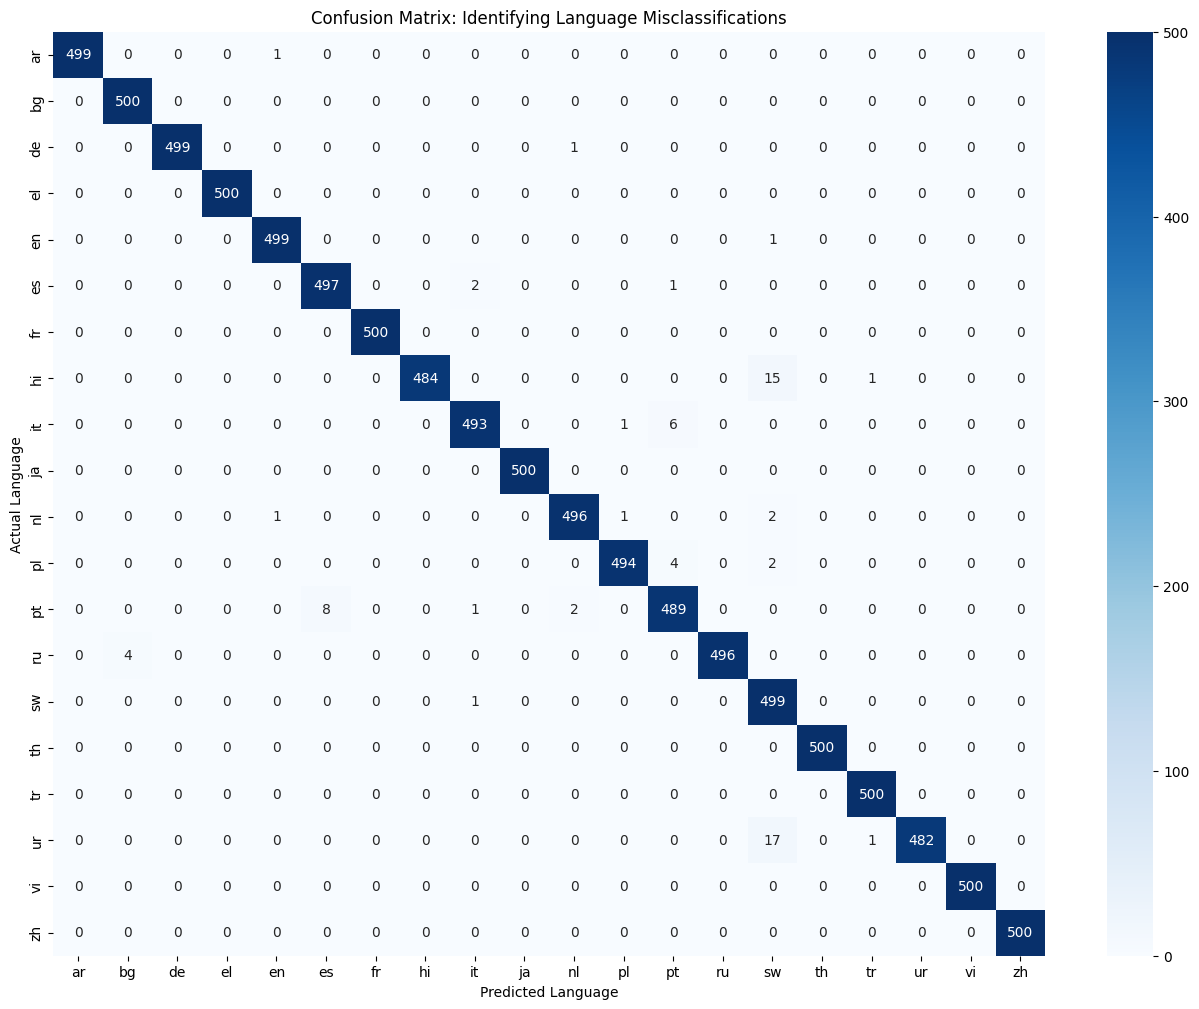

In [17]:
# 4. Visualize the Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=classes)
plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)

plt.ylabel('Actual Language')
plt.xlabel('Predicted Language')
plt.title('Confusion Matrix: Identifying Language Misclassifications')
plt.show()

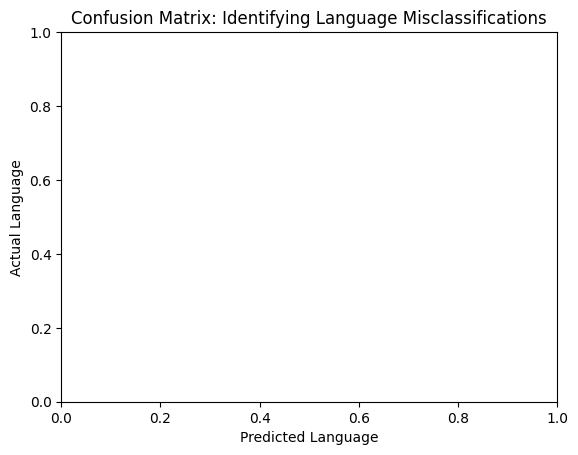

# Seralizing Model

In [18]:
import joblib
model_filename = "language_detector.pkl"
joblib.dump(pipeline, model_filename)
print(f"Module 1 completed and saved successfully as {model_filename}")

Module 1 completed and saved successfully as language_detector.pkl


# Inference

In [19]:
import joblib
import re
import string
import pandas as pd

# 1. The Preprocessing Function
# using def refined_clean_text(text):(Must match training exactly)

# 2. Load the Serialized Model
model_path = "language_detector.pkl"
try:
    print(f"Loading model from {model_path}...")
    pipeline = joblib.load(model_path)
    print("Model loaded successfully!\n")
except FileNotFoundError:
    print(f"Error: Could not find '{model_path}'. Ensure you are in the correct directory.")
    exit()

# 3. Define Test Samples
test_samples = [
    "I am feeling very anxious today and need help.",                 # English
    "مُكتئب جداً ولا أستطيع النوم منذ ٣ أيام",                          # Arabic (with Tashkeel and Eastern digits)
    "Je me sens très triste et isolé.",                               # French (with accents)
    "Estoy muy estresado por el trabajo, ¿qué hago?",                 # Spanish
    "Çok iyi",                                                        # Turkish (short text)
    "Я чувствую себя ужасно...",                                      # Russian (Cyrillic)
    "Watashi wa totemo kanashīdesu",                                  # Japanese (Romanized - might be tricky!)
    "मुझे बहुत तनाव महसूस हो रहा है।",                                   # Hindi (Devanagari)
    "https://example.com please help me @doctor I am sad 123",        # English (Heavy noise)
    "όνομα ;"                                                         # Greek (Short with punctuation)
]

# 4. Run Preprocessing
print("Cleaning test samples...")
cleaned_samples = [refined_clean_text(text) for text in test_samples]

# 5. Run Inference
print("Running predictions...\n")
predictions = pipeline.predict(cleaned_samples)

# Optional: Get prediction probabilities to see model confidence
probabilities = pipeline.predict_proba(cleaned_samples)
confidence_scores = [max(prob) * 100 for prob in probabilities]

# 6. Display Results
results_df = pd.DataFrame({
    "Original Text": test_samples,
    "Cleaned Text": cleaned_samples,
    "Predicted Lang": predictions,
    "Confidence": [f"{score:.2f}%" for score in confidence_scores]
})

pd.set_option('display.max_colwidth', None)
print(results_df.to_string(index=False))

Loading model from language_detector.pkl...
Model loaded successfully!

Cleaning test samples...
Running predictions...

                                          Original Text                                  Cleaned Text Predicted Lang Confidence
         I am feeling very anxious today and need help. i am feeling very anxious today and need help             en     78.22%
                مُكتئب جداً ولا أستطيع النوم منذ ٣ أيام       مُكتئب جداً ولا أستطيع النوم منذ ٣ أيام             ar     96.19%
                       Je me sens très triste et isolé.               je me sens très triste et isolé             fr     95.45%
         Estoy muy estresado por el trabajo, ¿qué hago?  estoy muy estresado por el trabajo ¿qué hago             es     91.70%
                                                Çok iyi                                       çok iyi             tr     91.13%
                              Я чувствую себя ужасно...                        я чувствую себя ужасно          

1. The Romanized Japanese (Predicted: Swahili, 95%)
This is a classic Out-of-Distribution (OOD) error.

- The Cause: The Hugging Face dataset we used trains the Japanese class (ja) using native Kanji, Hiragana, and Katakana characters. It has never seen Japanese written in English letters (Romaji).

- The "Swahili" Connection: Remember our confusion matrix where Hindi and Urdu occasionally misclassified as Swahili? The model learned that when it sees a string of Latin characters with unusual vowel-consonant groupings that don't match English, French, or Spanish, it assumes it's Swahili. It did the exact same thing here.

---
2. The Noisy English (Predicted: Swahili, 23%) <br />
- The Cause: The cleaned text was please help me i am sad. Why did it predict Swahili? Because the TF-IDF character n-grams for such a short, generic phrase didn't trigger strong English indicators.

# Inference Enhanced

In [20]:
import joblib
import re
import string
import pandas as pd

# 1. The Preprocessing Function (Must match training exactly)
def refined_clean_text(text):
    text = str(text)
    # Remove URLs and User Mentions
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    # Remove ONLY Western digits
    text = re.sub(r'[0-9]+', '', text)
    # Remove ONLY standard ASCII punctuation
    ascii_punctuation = re.escape(string.punctuation)
    text = re.sub(f'[{ascii_punctuation}]', ' ', text)
    # Normalize whitespace and lowercase
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

# 2. Load the Serialized Model
model_path = "language_detector.pkl"
try:
    print(f"Loading model from {model_path}...")
    pipeline = joblib.load(model_path)
    print("Model loaded successfully!\n")
except FileNotFoundError:
    print(f"Error: Could not find '{model_path}'. Ensure you are in the correct directory.")
    exit()

# 3. Define Test Samples
test_samples = [
    "I am feeling very anxious today and need help.",                 # English
    "مُكتئب جداً ولا أستطيع النوم منذ ٣ أيام",                          # Arabic (with Tashkeel and Eastern digits)
    "Je me sens très triste et isolé.",                               # French (with accents)
    "Estoy muy estresado por el trabajo, ¿qué hago?",                 # Spanish
    "Çok iyi",                                                        # Turkish (short text)
    "Я чувствую себя ужасно...",                                      # Russian (Cyrillic)
    "Watashi wa totemo kanashīdesu",                                  # Japanese (Romanized - might be tricky!)
    "मुझे बहुत तनाव महसूस हो रहा है।",                                   # Hindi (Devanagari)
    "https://example.com please help me @doctor I am sad 123",        # English (Heavy noise)
    "όνομα ;"                                                         # Greek (Short with punctuation)
]

# 4. Run Preprocessing
print("Cleaning test samples...")
cleaned_samples = [refined_clean_text(text) for text in test_samples]

# 5. Run Inference & Probabilities
print("Running predictions...\n")
predictions = pipeline.predict(cleaned_samples)
probabilities = pipeline.predict_proba(cleaned_samples)
confidence_scores = [max(prob) * 100 for prob in probabilities]

# 6. Apply Threshold Logic
THRESHOLD = 60.0
final_routes = []

for i in range(len(predictions)):
    if confidence_scores[i] < THRESHOLD:
        final_routes.append("en (Default Fallback)")
    else:
        final_routes.append(predictions[i])

# 7. Display Results
results_df = pd.DataFrame({
    "Original Text": test_samples,
    "Cleaned Text": cleaned_samples,
    "Predicted": predictions,
    "Confidence": [f"{score:.2f}%" for score in confidence_scores],
    "Final Route": final_routes
})

pd.set_option('display.max_colwidth', None)
print(results_df.to_string(index=False))

Loading model from language_detector.pkl...
Model loaded successfully!

Cleaning test samples...
Running predictions...

                                          Original Text                                  Cleaned Text Predicted Confidence           Final Route
         I am feeling very anxious today and need help. i am feeling very anxious today and need help        en     78.22%                    en
                مُكتئب جداً ولا أستطيع النوم منذ ٣ أيام       مُكتئب جداً ولا أستطيع النوم منذ ٣ أيام        ar     96.19%                    ar
                       Je me sens très triste et isolé.               je me sens très triste et isolé        fr     95.45%                    fr
         Estoy muy estresado por el trabajo, ¿qué hago?  estoy muy estresado por el trabajo ¿qué hago        es     91.70%                    es
                                                Çok iyi                                       çok iyi        tr     91.13%                    tr
         